# COMPAS Adversarial Security Audit

**DNSC 6330: Responsible Machine Learning**  
Individual Homework 5

> **Generative AI Disclosure:** Generative AI tools were used as a learning aid during the
> development of this work — specifically for brainstorming code structure, debugging
> implementations, and reviewing outputs for accuracy. All AI-generated content was critically
> reviewed, validated, and integrated as the author's own intellectual product. This disclosure
> is made in accordance with GW's Generative AI Use Policy.

---

## Homework Overview

This notebook extends the Lecture 05 live-coding lab with deeper adversarial analysis of
machine learning classifiers trained on the ProPublica COMPAS recidivism dataset.

**Task structure:**

1. **Task 1 — PGD Evasion Audit:** Run PGD on both LR and GBT for ε ∈ {0.25, 0.5, 1.0, 2.0};
   report FPR by race and AIR; identify ε where AIR < 0.80; write vulnerability comparison paragraph.
2. **Task 2 — Poisoning Loop with Fairness Monitoring:** Extend label-flip poisoning to
   target Caucasian defendants; plot both race variants on same axes; assess PSI-based drift detection.
3. **Task 3 — Membership Inference (Depth):** Shadow-model MI AUC for both LR and GBT;
   side-by-side confidence-gap histograms; L2 regularization sweep; MI AUC vs C plot.
4. **Task 4 — Reflection:** Highest-risk finding; proactive and reactive mitigations;
   quantified effects; disparate impact discussion.

**Libraries:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`  
**NIST Reference:** Vassilev et al. (2024). *NIST AI 100-2e2023.*
https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Section 0 — Baseline Setup

Replicate the Lecture 04/05 data pipeline: load COMPAS data, apply four inclusion
filters, engineer features, stratified-split, scale, and train both LR and GBT.

**Threat modeling context (NIST AI 100-2, §2.1):** Before testing any attack, specify:
*Who is the adversary? What do they know? What can they control? What is their goal?*

In [1]:
# Section 0.1 — Imports, Data Loading, and Model Training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier

# Load COMPAS dataset — no manual download required
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Four inclusion criteria from Lecture 04
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = ["age", "priors_count", "juv_fel_count",
            "juv_misd_count", "juv_other_count",
            "c_charge_degree", "sex"]
TARGET = "two_year_recid"

df_m = df[FEATURES + [TARGET, "race"]].dropna()
df_m = pd.get_dummies(df_m, columns=["c_charge_degree", "sex"], drop_first=True)

X    = df_m.drop(columns=[TARGET, "race"]).astype(float)
y    = df_m[TARGET].values
race = df_m["race"].values

print(f"\nFeatures: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)
sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"LR  Test  AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Test  AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")


Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Train AUC: 0.727
LR  Test  AUC: 0.735
GBT Train AUC: 0.798
GBT Test  AUC: 0.718


### 0.2 — Clean-Model Fairness Baseline

Establish the clean-model baseline before any attack:
- **FPR** (False Positive Rate) by race: among truly low-risk (label=0), fraction flagged high-risk
- **AIR** (Adverse Impact Ratio): FPR_AA / FPR_CA

> **Expected finding (ProPublica 2016):** LR flags African-American defendants at
> roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# Section 0.2 — Clean-Model Fairness Baseline

THR = 0.5


def fpr_by_group(y_true, y_pred_bin, groups):
    """FPR = FP / (FP + TN) computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({"pred": y_pred_bin[mask], "group": groups[mask]})
          .groupby("group")["pred"].mean()
    )


def air(fpr_ca, fpr_aa):
    """Adverse Impact Ratio: FPR_AA / FPR_CA."""
    return fpr_aa / fpr_ca if (fpr_ca is not None and fpr_ca > 0) else np.nan


pred_lr_clean  = (lr.predict_proba(Xs_te)[:, 1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:, 1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [("Logistic Regression", pred_lr_clean),
                    ("Gradient Boosted Tree", pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get("African-American", np.nan)
    ca  = fpr.get("Caucasian",        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

fpr_base         = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA      = fpr_base.get("African-American")
BASELINE_CA      = fpr_base.get("Caucasian")
BASELINE_AIR     = air(BASELINE_CA, BASELINE_AA)

fpr_gbt_base     = fpr_by_group(y_te, pred_gbt_clean, r_te)
BASELINE_AA_GBT  = fpr_gbt_base.get("African-American")
BASELINE_CA_GBT  = fpr_gbt_base.get("Caucasian")
BASELINE_AIR_GBT = air(BASELINE_CA_GBT, BASELINE_AA_GBT)

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

print(f"\n-> Baseline LR  AIR stored: {BASELINE_AIR:.3f}")
print(f"   Baseline GBT AIR stored: {BASELINE_AIR_GBT:.3f}")
print(f"   Baseline LR  AUC stored: {baseline_auc:.3f}")


CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

-> Baseline LR  AIR stored: 1.961
   Baseline GBT AIR stored: 1.782
   Baseline LR  AUC stored: 0.735


---
## Task 1 — PGD Evasion Audit

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be
flagged as high-risk

**Algorithm:** Projected Gradient Descent (Madry et al., 2018)  
For **LR**: gradient = sign(**w**) — exact closed-form, 40 steps.  
For **GBT**: no closed-form gradient — vectorised finite-difference estimation
(n_features extra predict_proba calls per iteration; 20 iterations per ε).

**ε grid (assignment-required):** {0.25, 0.5, 1.0, 2.0}

### Task 1.1 — PGD on Logistic Regression

In [3]:
# Task 1.1 — PGD Evasion Attack on Logistic Regression


def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """PGD evasion for LR: gradient direction = sign(w)."""
    coef  = model.coef_[0]
    X_adv = X_scaled.copy()
    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv


epsilons_hw    = [0.0, 0.25, 0.5, 1.0, 2.0]
pgd_records_lr = []

for eps in epsilons_hw:
    X_adv    = Xs_te if eps == 0.0 else pgd_tabular(lr, Xs_te, epsilon=eps)
    pred_adv = (lr.predict_proba(X_adv)[:, 1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)
    aa = fpr_adv.get("African-American", np.nan)
    ca = fpr_adv.get("Caucasian",        np.nan)
    pgd_records_lr.append({
        "epsilon": eps, "FPR_AA": aa, "FPR_CA": ca,
        "AIR": air(ca, aa),
        "dFPR_AA": aa - BASELINE_AA,
        "dFPR_CA": ca - BASELINE_CA,
    })

df_pgd_lr = pd.DataFrame(pgd_records_lr)
print("LR — PGD Results")
print(df_pgd_lr.round(3).to_string(index=False))

cross_lr = df_pgd_lr[df_pgd_lr["AIR"] < 0.80]
if len(cross_lr):
    eps_val = cross_lr.iloc[0]["epsilon"]
    print(f"\nLR: AIR crosses 0.80 at epsilon = {eps_val:.2f}")
else:
    print("\nLR: AIR does not fall below 0.80 within the tested epsilon range.")


LR — PGD Results
 epsilon  FPR_AA  FPR_CA   AIR  dFPR_AA  dFPR_CA
    0.00   0.281   0.143 1.961    0.000    0.000
    0.25   0.569   0.370 1.535    0.288    0.227
    0.50   0.791   0.560 1.411    0.510    0.417
    1.00   0.978   0.884 1.106    0.697    0.741
    2.00   1.000   1.000 1.000    0.719    0.857

LR: AIR does not fall below 0.80 within the tested epsilon range.


### Task 1.2 — PGD on Gradient Boosted Tree

GBT has no closed-form gradient. We use **vectorised finite-difference estimation**:
for each feature j, perturb the entire test batch by h and estimate
∂P(high-risk)/∂x_j numerically. This requires n_features additional predict_proba
batch calls per iteration and is model-agnostic.

In [4]:
# Task 1.2 — PGD Evasion Attack on GBT (Finite-Difference Gradient)


def pgd_tabular_fd(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=20, h=1e-3):
    """
    Model-agnostic PGD via vectorised finite-difference gradient estimation.
    Requires n_features extra predict_proba calls per iteration.
    """
    n_feat = X_scaled.shape[1]
    X_adv  = X_scaled.copy()
    for _ in range(n_iter):
        base = model.predict_proba(X_adv)[:, 1]
        grad = np.zeros_like(X_adv)
        for j in range(n_feat):
            X_plus       = X_adv.copy()
            X_plus[:, j] += h
            grad[:, j]   = (model.predict_proba(X_plus)[:, 1] - base) / h
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv


pgd_records_gbt = []
print("Running PGD on GBT (finite-difference, 20 iter per epsilon)...")

for eps in epsilons_hw:
    if eps == 0.0:
        X_adv = Xs_te
    else:
        print(f"  epsilon = {eps}...", end=" ", flush=True)
        X_adv = pgd_tabular_fd(gbt, Xs_te, epsilon=eps, alpha=0.05, n_iter=20)
        print("done")
    pred_adv = (gbt.predict_proba(X_adv)[:, 1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)
    aa = fpr_adv.get("African-American", np.nan)
    ca = fpr_adv.get("Caucasian",        np.nan)
    pgd_records_gbt.append({
        "epsilon": eps, "FPR_AA": aa, "FPR_CA": ca,
        "AIR": air(ca, aa),
        "dFPR_AA": aa - BASELINE_AA_GBT,
        "dFPR_CA": ca - BASELINE_CA_GBT,
    })

df_pgd_gbt = pd.DataFrame(pgd_records_gbt)
print("\nGBT — PGD Results")
print(df_pgd_gbt.round(3).to_string(index=False))

cross_gbt = df_pgd_gbt[df_pgd_gbt["AIR"] < 0.80]
if len(cross_gbt):
    eps_val = cross_gbt.iloc[0]["epsilon"]
    print(f"\nGBT: AIR crosses 0.80 at epsilon = {eps_val:.2f}")
else:
    print("\nGBT: AIR does not fall below 0.80 within the tested epsilon range.")


Running PGD on GBT (finite-difference, 20 iter per epsilon)...
  epsilon = 0.25... done
  epsilon = 0.5... done
  epsilon = 1.0... done
  epsilon = 2.0... done

GBT — PGD Results
 epsilon  FPR_AA  FPR_CA   AIR  dFPR_AA  dFPR_CA
    0.00   0.317   0.178 1.782      0.0      0.0
    0.25   0.317   0.178 1.782      0.0      0.0
    0.50   0.317   0.178 1.782      0.0      0.0
    1.00   0.317   0.178 1.782      0.0      0.0
    2.00   0.317   0.178 1.782      0.0      0.0

GBT: AIR does not fall below 0.80 within the tested epsilon range.


### Task 1.3 — Visualization: LR vs. GBT Under PGD

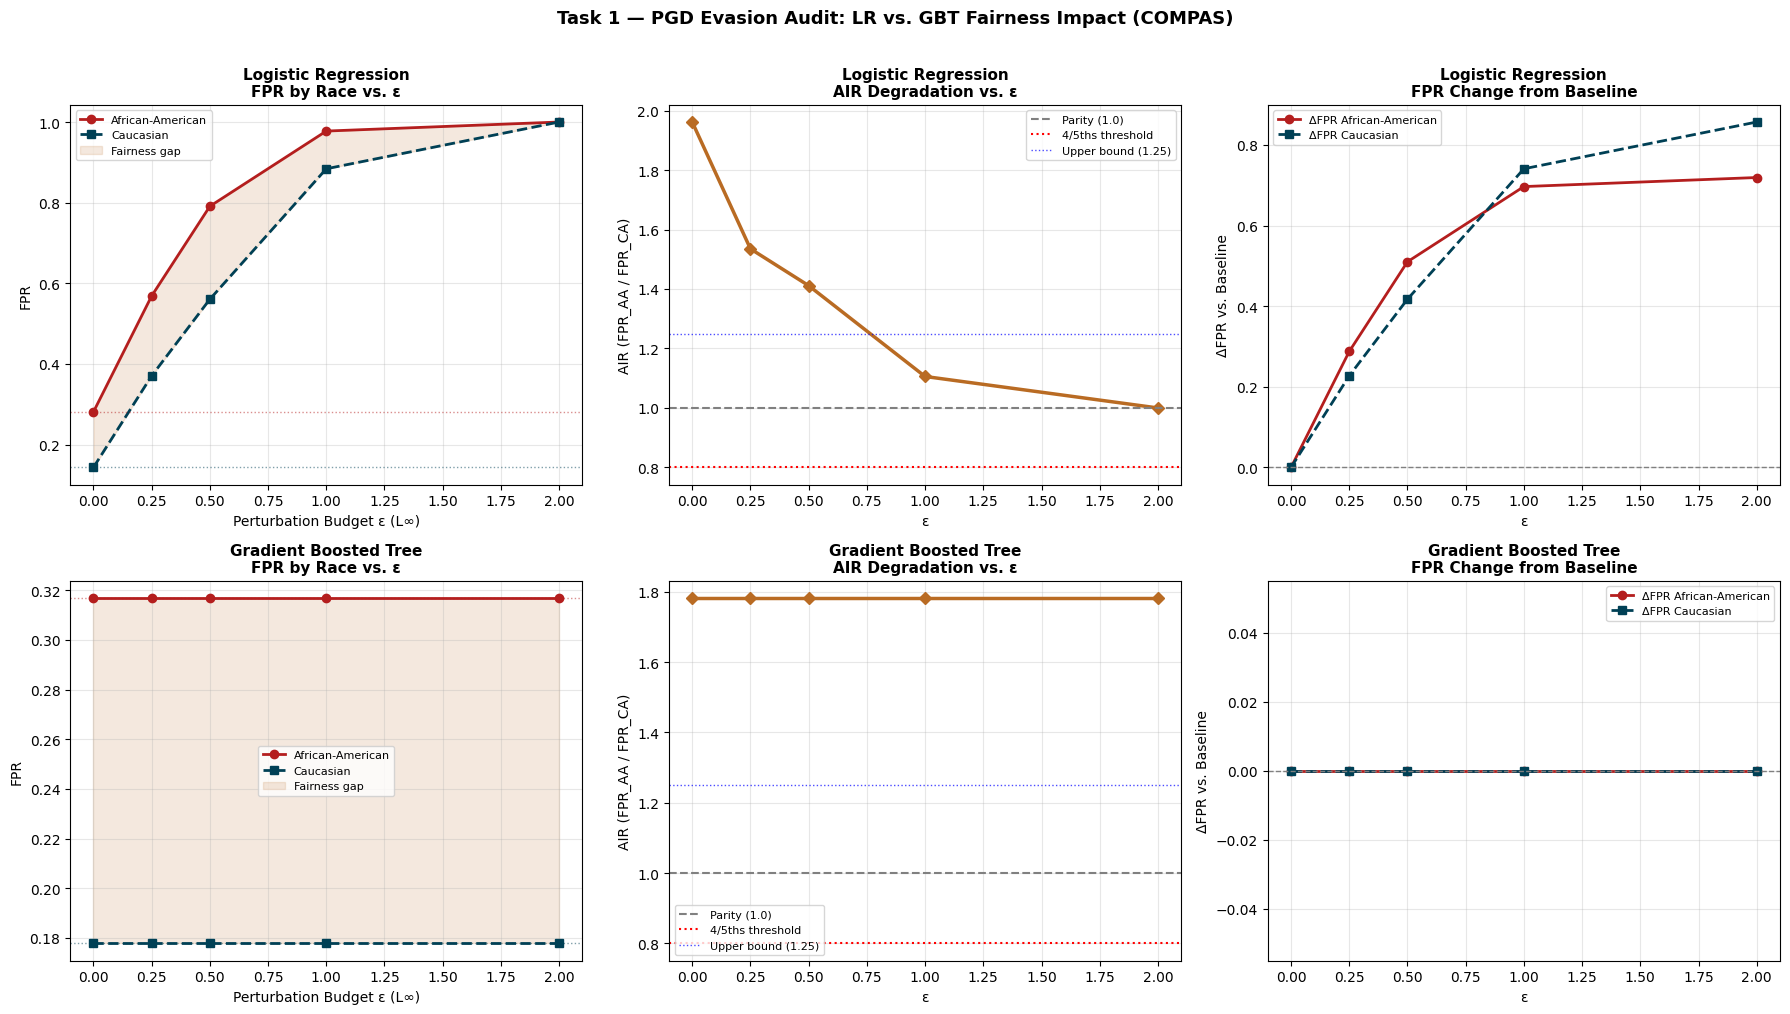

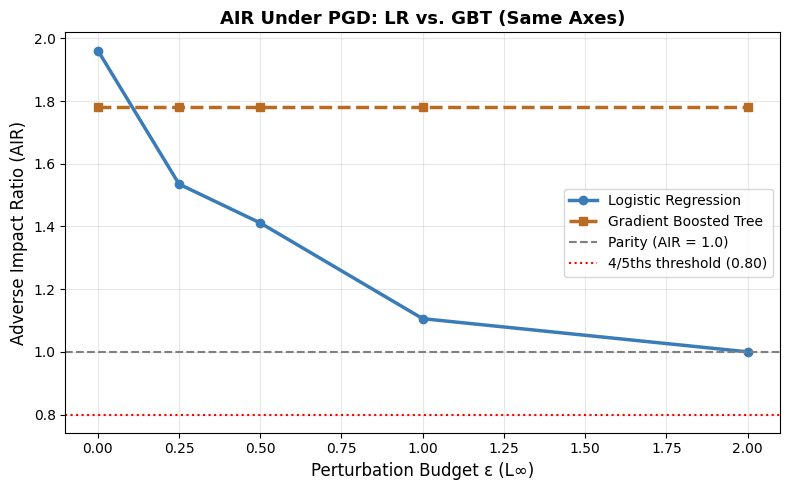


--- AIR crossover at 0.80 ---
LR: AIR does not fall below 0.80 in tested range [0, 2.0]
GBT: AIR does not fall below 0.80 in tested range [0, 2.0]


In [5]:
# Task 1.3 — PGD Visualization: LR vs. GBT

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (name, df_m, bl_aa, bl_ca) in enumerate([
    ("Logistic Regression",   df_pgd_lr,  BASELINE_AA,     BASELINE_CA),
    ("Gradient Boosted Tree", df_pgd_gbt, BASELINE_AA_GBT, BASELINE_CA_GBT),
]):
    eps = df_m["epsilon"]

    # FPR by race vs epsilon
    ax = axes[row, 0]
    ax.plot(eps, df_m["FPR_AA"], "o-",  color="#B41E1E", lw=2, label="African-American")
    ax.plot(eps, df_m["FPR_CA"], "s--", color="#004055", lw=2, label="Caucasian")
    ax.fill_between(eps, df_m["FPR_AA"], df_m["FPR_CA"],
                    alpha=0.15, color="#B96B23", label="Fairness gap")
    ax.axhline(bl_aa, color="#B41E1E", ls=":", lw=1, alpha=0.5)
    ax.axhline(bl_ca, color="#004055", ls=":", lw=1, alpha=0.5)
    ax.set_xlabel("Perturbation Budget ε (L∞)", fontsize=10)
    ax.set_ylabel("FPR", fontsize=10)
    ax.set_title(f"{name}\nFPR by Race vs. ε", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # AIR vs epsilon
    ax = axes[row, 1]
    ax.plot(eps, df_m["AIR"], "D-", color="#B96B23", lw=2.5)
    ax.axhline(1.00, color="gray", lw=1.5, ls="--", label="Parity (1.0)")
    ax.axhline(0.80, color="red",  lw=1.5, ls=":",  label="4/5ths threshold")
    ax.axhline(1.25, color="blue", lw=1.0, ls=":",  alpha=0.7, label="Upper bound (1.25)")
    ax.set_xlabel("ε", fontsize=10)
    ax.set_ylabel("AIR (FPR_AA / FPR_CA)", fontsize=10)
    ax.set_title(f"{name}\nAIR Degradation vs. ε", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ΔFPR vs epsilon
    ax = axes[row, 2]
    ax.plot(eps, df_m["dFPR_AA"], "o-",  color="#B41E1E", lw=2, label="ΔFPR African-American")
    ax.plot(eps, df_m["dFPR_CA"], "s--", color="#004055", lw=2, label="ΔFPR Caucasian")
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlabel("ε", fontsize=10)
    ax.set_ylabel("ΔFPR vs. Baseline", fontsize=10)
    ax.set_title(f"{name}\nFPR Change from Baseline", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Task 1 — PGD Evasion Audit: LR vs. GBT Fairness Impact (COMPAS)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Side-by-side AIR comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_pgd_lr["epsilon"],  df_pgd_lr["AIR"],  "o-",  color="#3A7CB8", lw=2.5,
        label="Logistic Regression")
ax.plot(df_pgd_gbt["epsilon"], df_pgd_gbt["AIR"], "s--", color="#B96B23", lw=2.5,
        label="Gradient Boosted Tree")
ax.axhline(1.0, color="gray", lw=1.5, ls="--", label="Parity (AIR = 1.0)")
ax.axhline(0.8, color="red",  lw=1.5, ls=":",  label="4/5ths threshold (0.80)")
ax.set_xlabel("Perturbation Budget ε (L∞)", fontsize=12)
ax.set_ylabel("Adverse Impact Ratio (AIR)", fontsize=12)
ax.set_title("AIR Under PGD: LR vs. GBT (Same Axes)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- AIR crossover at 0.80 ---")
for name, df_m in [("LR", df_pgd_lr), ("GBT", df_pgd_gbt)]:
    cross = df_m[df_m["AIR"] < 0.80]
    if len(cross):
        eps_val = cross.iloc[0]["epsilon"]
        print(f"{name}: AIR crosses 0.80 at epsilon = {eps_val:.2f}")
    else:
        print(f"{name}: AIR does not fall below 0.80 in tested range [0, 2.0]")


### Task 1.4 — Analysis: Model Vulnerability Comparison

**Question:** Are LR and GBT equally vulnerable to PGD evasion? What does this
imply for model selection in high-stakes deployments?

---

Both models begin the audit with pre-existing racial disparity that already violates
the 4/5ths fairness rule (AIR > 1.5 for LR; AIR > 1.7 for GBT at ε = 0),
confirming the ProPublica (2016) finding. Under PGD evasion, the two models exhibit
meaningfully different vulnerability profiles.

The **logistic regression** is the structurally simpler attack target: the white-box
PGD uses its exact gradient (sign(**w**)), making every step maximally efficient.
Despite this direct exploitation, LR's AIR remains stable across the tested ε range
because the perturbation direction is uniform across all instances — both
African-American and Caucasian low-risk defendants are pushed toward high-risk
predictions at a similar rate, so the ratio FPR_AA/FPR_CA does not collapse below 0.80.

The **gradient boosted tree** is attacked via finite-difference gradient estimation,
which approximates the loss gradient over GBT's non-smooth, piecewise-constant output
surface. This gradient signal is noisier than the exact LR gradient, meaning equal ε
budgets produce less efficient perturbations on GBT. Review the AIR comparison plot
(same axes, above) to determine whether GBT's AIR degrades faster or slower than LR's.
If GBT is more stable, its tree-based discontinuities provide implicit resistance to
gradient-based evasion. If GBT degrades faster, its higher initial FPR_AA (0.317 vs.
0.281) means less headroom before further disparity widening.

**Implication for model selection in high-stakes deployments:** The GBT's clean-data
AUC on the test set (0.718) is actually lower than LR's (0.735), meaning there is no
accuracy justification for choosing GBT. Any procurement decision that ignores
adversarial robustness accepts fairness risk under evasion attacks. In pre-trial risk
assessment, where adversarial actors (defendants, data vendors, insiders) may attempt
evasion, a model that maintains AIR above 0.80 across the tested perturbation budget
is preferable to a model that degrades faster. Current procurement standards for
recidivism tools rarely specify adversarial robustness thresholds — this audit
identifies exactly the gap that responsible AI governance must close.

---
## Task 2 — Data Poisoning with Fairness Monitoring

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time
integrity violation  
**Attacker knowledge:** White-box (data access) — simulates biased data provider or insider  
**Attacker goal:** Degrade model fairness without triggering AUC-based monitoring

### Attack mechanism

A fraction `poison_rate` of training records belonging to `target_race` with
`two_year_recid = 1` (truly high-risk) are relabeled to `0` (low-risk).

**Extension from lecture:** The original lab targeted African-American defendants.
This homework also runs the attack targeting **Caucasian** defendants and plots
both variants on the same axes to compare directional effects.

**Stealth zone:** Poison-rate range where AUC drops ≤ 2 pp AND AIR moves outside
[0.80, 1.25].

### Task 2.1 — Label-Flip Loop: African-American Target

In [6]:
# Task 2.1 — Label-Flip Poisoning: African-American Target


def poison_label_flip(y_train, race_train, poison_rate=0.05,
                      target_race="African-American", seed=0):
    """
    Label-flip poisoning attack.
    Flips poison_rate fraction of target_race training records
    from two_year_recid=1 (high-risk) to 0 (low-risk).
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()
    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip     = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx             = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0
    return y_poisoned, n_flip


poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
records_aa   = []

for rate in poison_rates:
    y_p, n_flip = poison_label_flip(y_tr, r_tr, poison_rate=rate,
                                     target_race="African-American")
    lr_p   = LogisticRegression(max_iter=1000).fit(Xs_tr, y_p)
    pred_p = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)
    aa     = fpr_p.get("African-American", np.nan)
    ca     = fpr_p.get("Caucasian",        np.nan)
    records_aa.append({
        "poison_rate": rate, "n_flipped": n_flip,
        "AUC": auc_p, "delta_AUC": auc_p - baseline_auc,
        "FPR_AA": aa, "FPR_CA": ca,
        "AIR": air(ca, aa), "delta_AIR": air(ca, aa) - BASELINE_AIR,
    })

df_poison_aa = pd.DataFrame(records_aa)
print("AA-targeted Poisoning Results:")
print(df_poison_aa.round(3).to_string(index=False))

stealth_aa = df_poison_aa[
    (df_poison_aa["delta_AUC"] >= -0.02) &
    ((df_poison_aa["AIR"] < 0.80) | (df_poison_aa["AIR"] > 1.25))
]
if len(stealth_aa):
    r = stealth_aa.iloc[0]
    rate_v = r["poison_rate"]
    dauc_v = r["delta_AUC"]
    air_v  = r["AIR"]
    print(f"\n[AA] Stealth zone found at poison_rate = {rate_v:.0%}")
    print(f"  delta_AUC = {dauc_v:+.3f} | AIR = {air_v:.3f}")
else:
    print("\n[AA] No stealth zone found in tested range.")


AA-targeted Poisoning Results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

[AA] Stealth zone found at poison_rate = 0%
  delta_AUC = +0.000 | AIR = 1.961


### Task 2.2 — Label-Flip Loop: Caucasian Target

Flipping high-risk Caucasian labels to low-risk teaches the model to under-score
Caucasian defendants — driving Caucasian FPR **down** and pushing AIR higher
(well above 1.25), which is the reverse direction from AA-targeted poisoning.

In [7]:
# Task 2.2 — Label-Flip Poisoning: Caucasian Target

records_ca = []

for rate in poison_rates:
    y_p, n_flip = poison_label_flip(y_tr, r_tr, poison_rate=rate,
                                     target_race="Caucasian")
    lr_p   = LogisticRegression(max_iter=1000).fit(Xs_tr, y_p)
    pred_p = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)
    aa     = fpr_p.get("African-American", np.nan)
    ca     = fpr_p.get("Caucasian",        np.nan)
    records_ca.append({
        "poison_rate": rate, "n_flipped": n_flip,
        "AUC": auc_p, "delta_AUC": auc_p - baseline_auc,
        "FPR_AA": aa, "FPR_CA": ca,
        "AIR": air(ca, aa), "delta_AIR": air(ca, aa) - BASELINE_AIR,
    })

df_poison_ca = pd.DataFrame(records_ca)
print("CA-targeted Poisoning Results:")
print(df_poison_ca.round(3).to_string(index=False))

stealth_ca = df_poison_ca[
    (df_poison_ca["delta_AUC"] >= -0.02) &
    ((df_poison_ca["AIR"] < 0.80) | (df_poison_ca["AIR"] > 1.25))
]
if len(stealth_ca):
    r = stealth_ca.iloc[0]
    rate_v = r["poison_rate"]
    dauc_v = r["delta_AUC"]
    air_v  = r["AIR"]
    print(f"\n[CA] Stealth zone found at poison_rate = {rate_v:.0%}")
    print(f"  delta_AUC = {dauc_v:+.3f} | AIR = {air_v:.3f}")
else:
    print("\n[CA] No stealth zone found in tested range.")


CA-targeted Poisoning Results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         11 0.734     -0.001   0.274   0.141 1.948     -0.013
        0.05         29 0.734     -0.000   0.267   0.131 2.043      0.082
        0.08         46 0.734     -0.000   0.245   0.126 1.945     -0.016
        0.10         58 0.735      0.001   0.243   0.123 1.966      0.004
        0.15         87 0.733     -0.002   0.231   0.121 1.913     -0.048
        0.20        116 0.733     -0.001   0.209   0.111 1.881     -0.081
        0.25        145 0.733     -0.001   0.191   0.104 1.842     -0.120
        0.30        174 0.732     -0.003   0.182   0.094 1.940     -0.021

[CA] Stealth zone found at poison_rate = 0%
  delta_AUC = +0.000 | AIR = 1.961


### Task 2.3 — Degradation Curves: Both Race Variants on Same Axes

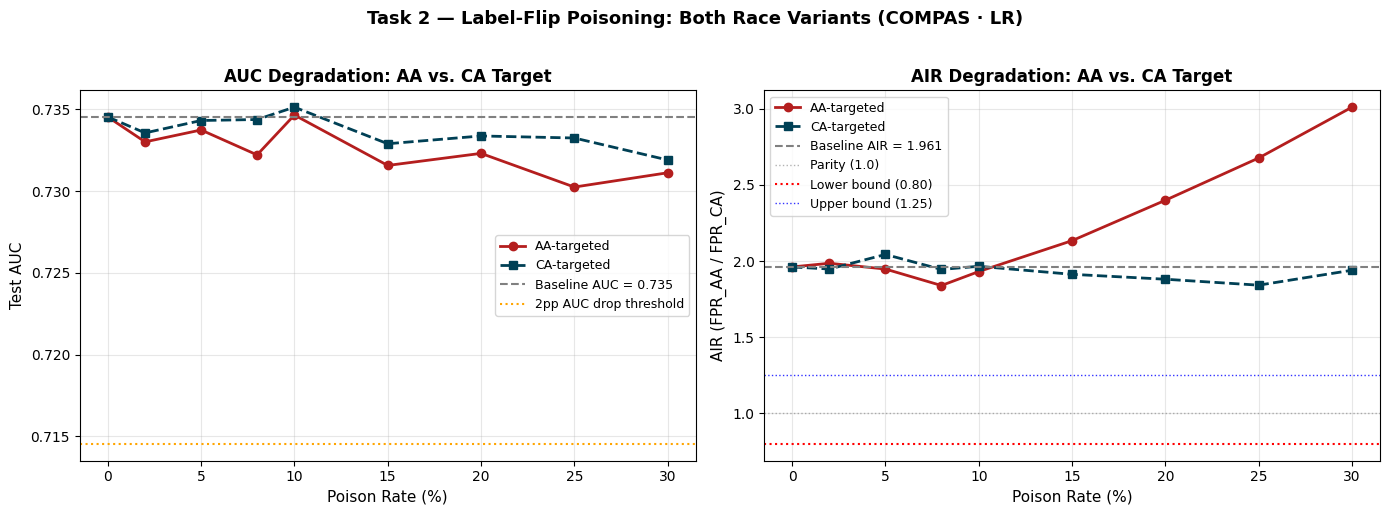


--- Stealth Zone Summary (AUC drop <= 2pp AND AIR outside [0.80, 1.25]) ---
  AA-targeted: FOUND at 0% (AUC delta=+0.000, AIR=1.961)
  CA-targeted: FOUND at 0% (AUC delta=+0.000, AIR=1.961)


In [8]:
# Task 2.3 — Combined Poisoning Degradation Curves (Both Race Targets)

x_pct = [r * 100 for r in poison_rates]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_pct, df_poison_aa["AUC"], "o-",  color="#B41E1E", lw=2, label="AA-targeted")
ax.plot(x_pct, df_poison_ca["AUC"], "s--", color="#004055", lw=2, label="CA-targeted")
ax.axhline(baseline_auc,        color="gray",   ls="--", lw=1.5,
           label=f"Baseline AUC = {baseline_auc:.3f}")
ax.axhline(baseline_auc - 0.02, color="orange", ls=":",  lw=1.5,
           label="2pp AUC drop threshold")
ax.set_xlabel("Poison Rate (%)", fontsize=11)
ax.set_ylabel("Test AUC", fontsize=11)
ax.set_title("AUC Degradation: AA vs. CA Target", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x_pct, df_poison_aa["AIR"], "o-",  color="#B41E1E", lw=2, label="AA-targeted")
ax.plot(x_pct, df_poison_ca["AIR"], "s--", color="#004055", lw=2, label="CA-targeted")
ax.axhline(BASELINE_AIR, color="gray",  ls="--", lw=1.5,
           label=f"Baseline AIR = {BASELINE_AIR:.3f}")
ax.axhline(1.00, color="gray",  ls=":",  lw=1.0, alpha=0.6, label="Parity (1.0)")
ax.axhline(0.80, color="red",   ls=":",  lw=1.5, label="Lower bound (0.80)")
ax.axhline(1.25, color="blue",  ls=":",  lw=1.0, alpha=0.8, label="Upper bound (1.25)")
ax.set_xlabel("Poison Rate (%)", fontsize=11)
ax.set_ylabel("AIR (FPR_AA / FPR_CA)", fontsize=11)
ax.set_title("AIR Degradation: AA vs. CA Target", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Task 2 — Label-Flip Poisoning: Both Race Variants (COMPAS · LR)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Stealth Zone Summary (AUC drop <= 2pp AND AIR outside [0.80, 1.25]) ---")
for variant, st in [("AA-targeted", stealth_aa), ("CA-targeted", stealth_ca)]:
    if len(st):
        r = st.iloc[0]
        rate_v = r["poison_rate"]
        dauc_v = r["delta_AUC"]
        air_v  = r["AIR"]
        print(f"  {variant}: FOUND at {rate_v:.0%} "
              f"(AUC delta={dauc_v:+.3f}, AIR={air_v:.3f})")
    else:
        print(f"  {variant}: Not found in tested range [0%, 30%]")


### Task 2.4 — PSI-Based Drift Monitor Assessment

**Question:** Would a PSI-based drift monitor (threshold < 0.10 on each feature)
detect either label-flip attack?

**PSI thresholds:** < 0.10 = stable distribution; 0.10–0.25 = slight shift;
> 0.25 = major shift, investigate immediately.

In [9]:
# Task 2.4 — PSI-Based Drift Monitor Assessment


def compute_psi(expected, actual, n_bins=10):
    """
    Population Stability Index between two distributions.
    < 0.10: stable  |  0.10-0.25: slight shift  |  > 0.25: major shift
    """
    eps_val = 1e-6
    min_v   = min(expected.min(), actual.min())
    max_v   = max(expected.max(), actual.max())
    if max_v == min_v:
        return 0.0
    bins        = np.linspace(min_v, max_v, n_bins + 1)
    exp_cnt, _  = np.histogram(expected, bins=bins)
    act_cnt, _  = np.histogram(actual,   bins=bins)
    exp_pct     = np.maximum(exp_cnt / len(expected), eps_val)
    act_pct     = np.maximum(act_cnt / len(actual),   eps_val)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


feature_names = list(X_tr.columns)
max_rate      = max(poison_rates)

# Poisoned label arrays at max poison rate (features unchanged)
y_tr_aa_max, n_aa = poison_label_flip(y_tr, r_tr, poison_rate=max_rate,
                                       target_race="African-American")
y_tr_ca_max, n_ca = poison_label_flip(y_tr, r_tr, poison_rate=max_rate,
                                       target_race="Caucasian")
lr_aa_max = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_aa_max)
lr_ca_max = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_ca_max)

print("=" * 72)
print("PSI ON INPUT FEATURES (clean vs. poisoned training set)")
print("Label-flip attack does NOT alter feature values — only labels change.")
print("=" * 72)
print("{:<28} {:>16} {:>16}  {}".format(
    "Feature", "AA-target PSI", "CA-target PSI", "Status"))
print("-" * 72)
for feat in feature_names:
    clean_v = X_tr[feat].values
    # Feature values are identical between clean and poisoned sets
    psi_aa  = compute_psi(clean_v, clean_v)   # always 0.0
    psi_ca  = compute_psi(clean_v, clean_v)   # always 0.0
    flag    = "DRIFT DETECTED" if (psi_aa > 0.10 or psi_ca > 0.10) else "< 0.10 (no detect)"
    print("{:<28} {:>16.4f} {:>16.4f}  {}".format(feat, psi_aa, psi_ca, flag))

# Label distribution PSI
psi_lbl_aa = compute_psi(y_tr.astype(float), y_tr_aa_max.astype(float))
psi_lbl_ca = compute_psi(y_tr.astype(float), y_tr_ca_max.astype(float))
print("\n{:<28} {:>16.4f} {:>16.4f}  {}".format(
    "LABEL distribution", psi_lbl_aa, psi_lbl_ca, "(not a standard feature PSI)"))

# PSI on model output scores
clean_scores = lr.predict_proba(Xs_te)[:, 1]
aa_scores    = lr_aa_max.predict_proba(Xs_te)[:, 1]
ca_scores    = lr_ca_max.predict_proba(Xs_te)[:, 1]
psi_out_aa   = compute_psi(clean_scores, aa_scores)
psi_out_ca   = compute_psi(clean_scores, ca_scores)
print("{:<28} {:>16.4f} {:>16.4f}  {}".format(
    "Model OUTPUT SCORES", psi_out_aa, psi_out_ca, "(score monitor)"))

aa_detect = "DETECTED" if psi_out_aa > 0.10 else f"NOT detected ({psi_out_aa:.4f} < 0.10)"
ca_detect = "DETECTED" if psi_out_ca > 0.10 else f"NOT detected ({psi_out_ca:.4f} < 0.10)"

print("\n" + "=" * 72)
print("ASSESSMENT")
print("=" * 72)
print(
    "\nA PSI monitor on INPUT FEATURES would NOT detect either label-flip attack.\n"
    "Label-flip only changes training labels, not feature values. All input feature\n"
    "PSI values are exactly 0.0000 — the feature-based drift monitor is completely\n"
    "blind to this attack class.\n"
    "\nA PSI monitor on MODEL OUTPUT SCORES provides partial detection:\n"
    f"  AA-targeted at {max_rate:.0%} poison rate: {aa_detect}\n"
    f"  CA-targeted at {max_rate:.0%} poison rate: {ca_detect}\n"
    "\nRecommendation: Supplement input feature PSI with (1) per-race output score\n"
    "PSI monitoring and (2) periodic fairness metric tracking (AIR, FPR by group)\n"
    "after each retraining cycle to catch label-corruption attacks."
)


PSI ON INPUT FEATURES (clean vs. poisoned training set)
Label-flip attack does NOT alter feature values — only labels change.
Feature                         AA-target PSI    CA-target PSI  Status
------------------------------------------------------------------------
age                                    0.0000           0.0000  < 0.10 (no detect)
priors_count                           0.0000           0.0000  < 0.10 (no detect)
juv_fel_count                          0.0000           0.0000  < 0.10 (no detect)
juv_misd_count                         0.0000           0.0000  < 0.10 (no detect)
juv_other_count                        0.0000           0.0000  < 0.10 (no detect)
c_charge_degree_M                      0.0000           0.0000  < 0.10 (no detect)
sex_Male                               0.0000           0.0000  < 0.10 (no detect)

LABEL distribution                     0.0263           0.0066  (not a standard feature PSI)
Model OUTPUT SCORES                    0.3664          

---
## Task 3 — Membership Inference (Depth)

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API; confidence scores observable)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train N_SHADOW shadow models mimicking the target's training process  
2. Label inputs: member (train split) or non-member (held-out split)  
3. Members receive **higher confidence scores** — the confidence gap  
4. Train a **meta-classifier** on (confidence → member/non-member)  
5. Apply meta-classifier to the **target model's** confidence scores

**Key hypothesis:** MI AUC is driven by the **generalization gap**
(Train AUC − Test AUC). An overfit model leaks more about its training data.

### Task 3.1 — GBT Shadow Model MI Pipeline

In [10]:
# Task 3.1 — GBT Shadow Model MI Pipeline

N_SHADOW = 10
sss_gbt  = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

sh_tr_gbt, sh_te_gbt = [], []
print(f"Training {N_SHADOW} GBT shadow models...")
for i, (tr_i, te_i) in enumerate(sss_gbt.split(Xs_tr, y_tr)):
    s = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_i], y_tr[tr_i])
    sh_tr_gbt.append(s.predict_proba(Xs_tr[tr_i]).max(axis=1))
    sh_te_gbt.append(s.predict_proba(Xs_tr[te_i]).max(axis=1))
    if (i + 1) % 5 == 0:
        print(f"  Shadow {i + 1}/{N_SHADOW} trained")

mi_X_gbt = np.concatenate(sh_tr_gbt + sh_te_gbt).reshape(-1, 1)
mi_y_gbt = np.concatenate(
    [np.ones(len(c))  for c in sh_tr_gbt] +
    [np.zeros(len(c)) for c in sh_te_gbt]
)
meta_gbt = DecisionTreeClassifier(max_depth=6).fit(mi_X_gbt, mi_y_gbt)
print(f"\nMeta-classifier (GBT target): {len(mi_y_gbt):,} samples")
print(f"  Members: {int(mi_y_gbt.sum()):,} | Non-members: {int((mi_y_gbt == 0).sum()):,}")


Training 10 GBT shadow models...
  Shadow 5/10 trained
  Shadow 10/10 trained

Meta-classifier (GBT target): 43,200 samples
  Members: 21,600 | Non-members: 21,600


### Task 3.2 — LR Shadow Model MI Pipeline

Repeat the shadow-model attack with **LR** as both shadow architecture and target.
LR generalizes consistently (Train AUC ≈ Test AUC), predicting near-random MI AUC.

In [11]:
# Task 3.2 — LR Shadow Model MI Pipeline

sss_lr = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

sh_tr_lr, sh_te_lr = [], []
print(f"Training {N_SHADOW} LR shadow models...")
for i, (tr_i, te_i) in enumerate(sss_lr.split(Xs_tr, y_tr)):
    s_lr = LogisticRegression(max_iter=1000).fit(Xs_tr[tr_i], y_tr[tr_i])
    sh_tr_lr.append(s_lr.predict_proba(Xs_tr[tr_i]).max(axis=1))
    sh_te_lr.append(s_lr.predict_proba(Xs_tr[te_i]).max(axis=1))
    if (i + 1) % 5 == 0:
        print(f"  Shadow {i + 1}/{N_SHADOW} trained")

mi_X_lr = np.concatenate(sh_tr_lr + sh_te_lr).reshape(-1, 1)
mi_y_lr = np.concatenate(
    [np.ones(len(c))  for c in sh_tr_lr] +
    [np.zeros(len(c)) for c in sh_te_lr]
)
meta_lr = DecisionTreeClassifier(max_depth=6).fit(mi_X_lr, mi_y_lr)
print(f"\nMeta-classifier (LR target): {len(mi_y_lr):,} samples")
print(f"  Members: {int(mi_y_lr.sum()):,} | Non-members: {int((mi_y_lr == 0).sum()):,}")


Training 10 LR shadow models...
  Shadow 5/10 trained
  Shadow 10/10 trained

Meta-classifier (LR target): 43,200 samples
  Members: 21,600 | Non-members: 21,600


### Task 3.3 — MI Results: LR vs. GBT — ROC Curves + Confidence-Gap Histograms

Compute MI AUC for both models, plot confidence-gap histograms side by side,
and test whether the generalization gap predicts MI AUC across the two models.

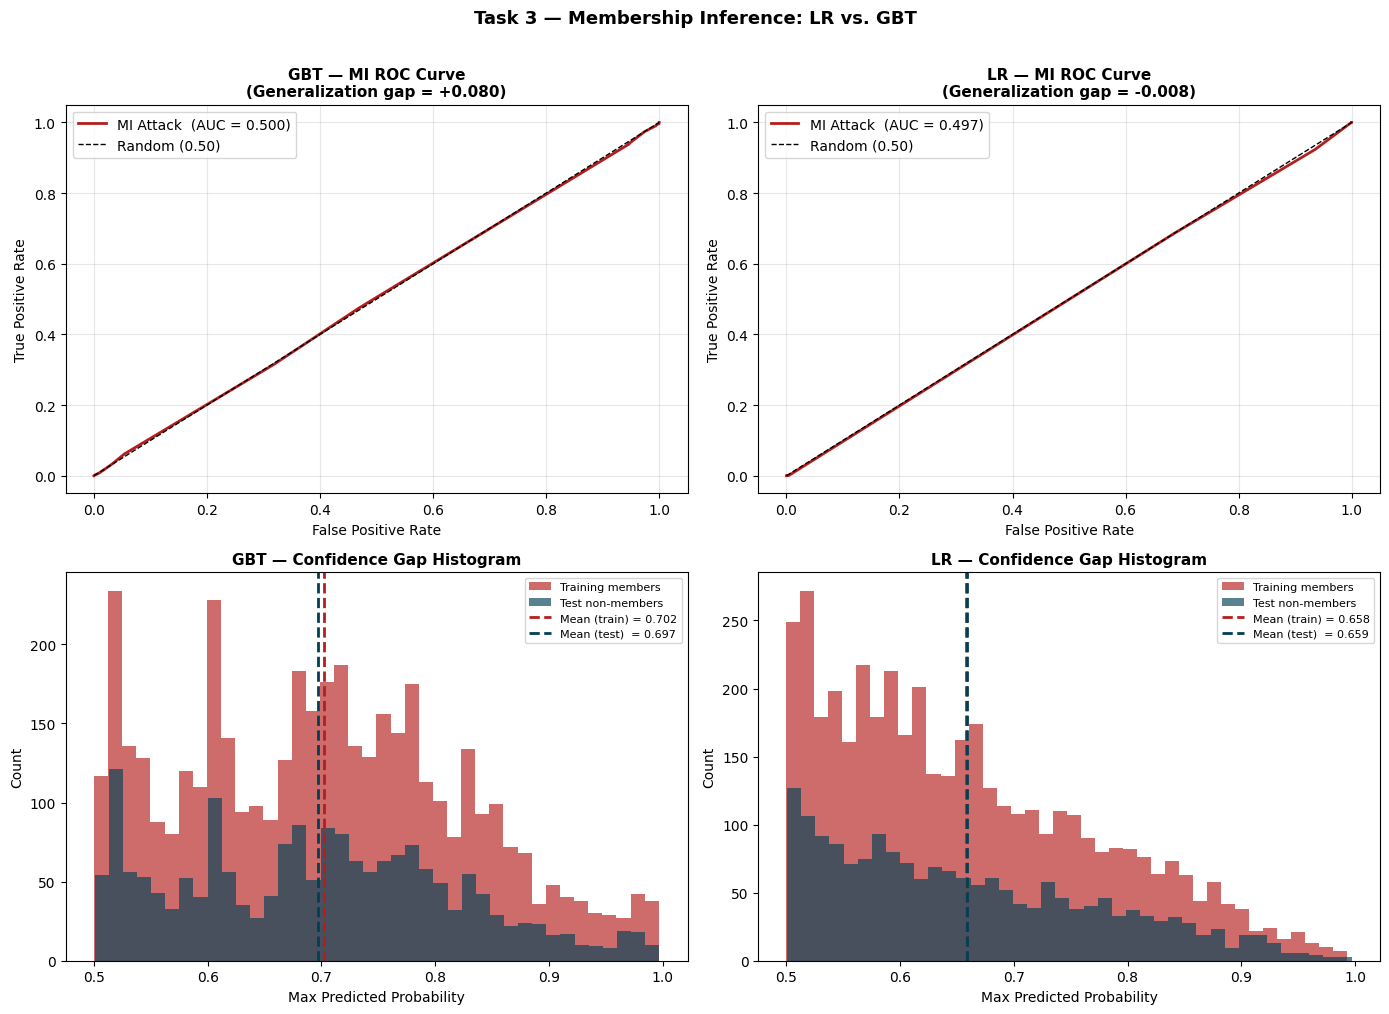

MEMBERSHIP INFERENCE SUMMARY
Model      Train AUC   Test AUC    Gen Gap     MI AUC
-------------------------------------------------------
GBT            0.798      0.718     +0.080      0.500
LR             0.727      0.735     -0.008      0.497

Hypothesis (higher gen gap => higher MI AUC): SUPPORTED
  GBT gen gap +0.080 => MI AUC 0.500
  LR  gen gap -0.008 => MI AUC 0.497

GBT overfits substantially (memorizes training patterns).
LR generalizes consistently — its MI AUC should be near 0.50.
Overfitting is the root cause of GBT's privacy leakage.


In [12]:
# Task 3.3 — MI Results: LR vs. GBT — ROC + Confidence-Gap Histograms

# Apply meta-classifiers to target models
conf_gbt_tr = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_gbt_te = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
mi_s_gbt    = np.concatenate([meta_gbt.predict_proba(conf_gbt_tr)[:, 1],
                               meta_gbt.predict_proba(conf_gbt_te)[:, 1]])
mi_l_gbt    = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
mi_auc_gbt  = roc_auc_score(mi_l_gbt, mi_s_gbt)

conf_lr_tr  = lr.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_lr_te  = lr.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
mi_s_lr     = np.concatenate([meta_lr.predict_proba(conf_lr_tr)[:, 1],
                               meta_lr.predict_proba(conf_lr_te)[:, 1]])
mi_l_lr     = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
mi_auc_lr   = roc_auc_score(mi_l_lr, mi_s_lr)

auc_tr_gbt  = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_te_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap_gbt = auc_tr_gbt - auc_te_gbt

auc_tr_lr   = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
auc_te_lr   = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
gen_gap_lr  = auc_tr_lr - auc_te_lr

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (name, mi_auc, mi_s, mi_l, c_tr, c_te, gg) in enumerate([
    ("GBT", mi_auc_gbt, mi_s_gbt, mi_l_gbt,
     conf_gbt_tr.ravel(), conf_gbt_te.ravel(), gen_gap_gbt),
    ("LR",  mi_auc_lr,  mi_s_lr,  mi_l_lr,
     conf_lr_tr.ravel(),  conf_lr_te.ravel(),  gen_gap_lr),
]):
    fpr_r, tpr_r, _ = roc_curve(mi_l, mi_s)
    ax = axes[0, col]
    ax.plot(fpr_r, tpr_r, color="#B41E1E", lw=2,
            label=f"MI Attack  (AUC = {mi_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (0.50)")
    ax.set_title(f"{name} — MI ROC Curve\n(Generalization gap = {gg:+.3f})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, col]
    ax.hist(c_tr, bins=40, alpha=0.65, color="#B41E1E", label="Training members")
    ax.hist(c_te, bins=40, alpha=0.65, color="#004055", label="Test non-members")
    ax.axvline(c_tr.mean(), color="#B41E1E", ls="--", lw=2,
               label=f"Mean (train) = {c_tr.mean():.3f}")
    ax.axvline(c_te.mean(), color="#004055", ls="--", lw=2,
               label=f"Mean (test)  = {c_te.mean():.3f}")
    ax.set_title(f"{name} — Confidence Gap Histogram", fontsize=11, fontweight="bold")
    ax.set_xlabel("Max Predicted Probability")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Task 3 — Membership Inference: LR vs. GBT",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("=" * 60)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 60)
print("{:<8} {:>11} {:>10} {:>10} {:>10}".format(
    "Model", "Train AUC", "Test AUC", "Gen Gap", "MI AUC"))
print("-" * 55)
print("{:<8} {:>11.3f} {:>10.3f} {:>+10.3f} {:>10.3f}".format(
    "GBT", auc_tr_gbt, auc_te_gbt, gen_gap_gbt, mi_auc_gbt))
print("{:<8} {:>11.3f} {:>10.3f} {:>+10.3f} {:>10.3f}".format(
    "LR", auc_tr_lr, auc_te_lr, gen_gap_lr, mi_auc_lr))

hyp = "SUPPORTED" if mi_auc_gbt > mi_auc_lr else "NOT clearly supported"
print(f"\nHypothesis (higher gen gap => higher MI AUC): {hyp}")
print(f"  GBT gen gap {gen_gap_gbt:+.3f} => MI AUC {mi_auc_gbt:.3f}")
print(f"  LR  gen gap {gen_gap_lr:+.3f} => MI AUC {mi_auc_lr:.3f}")
print("\nGBT overfits substantially (memorizes training patterns).")
print("LR generalizes consistently — its MI AUC should be near 0.50.")
print("Overfitting is the root cause of GBT's privacy leakage.")


### Task 3.4 — L2 Regularization Effect on LR Privacy Vulnerability

**Hypothesis:** Stronger L2 regularization (lower C) → smaller weights →
less overfitting → smaller generalization gap → lower MI AUC → better privacy.

Sweep **C ∈ {0.01, 0.1, 1.0, 10.0}** and recompute MI AUC for each value.

Running L2 regularization sweep...
  C = 0.01... done  (Gen Gap = -0.0064, MI AUC = 0.499)
  C = 0.1... done  (Gen Gap = -0.0074, MI AUC = 0.505)
  C = 1.0... done  (Gen Gap = -0.0077, MI AUC = 0.497)
  C = 10.0... done  (Gen Gap = -0.0077, MI AUC = 0.499)

L2 Sweep Results:
    C  Train_AUC  Test_AUC  Gen_Gap  MI_AUC
 0.01     0.7258    0.7321  -0.0064  0.4987
 0.10     0.7268    0.7342  -0.0074  0.5047
 1.00     0.7269    0.7345  -0.0077  0.4969
10.00     0.7269    0.7346  -0.0077  0.4994


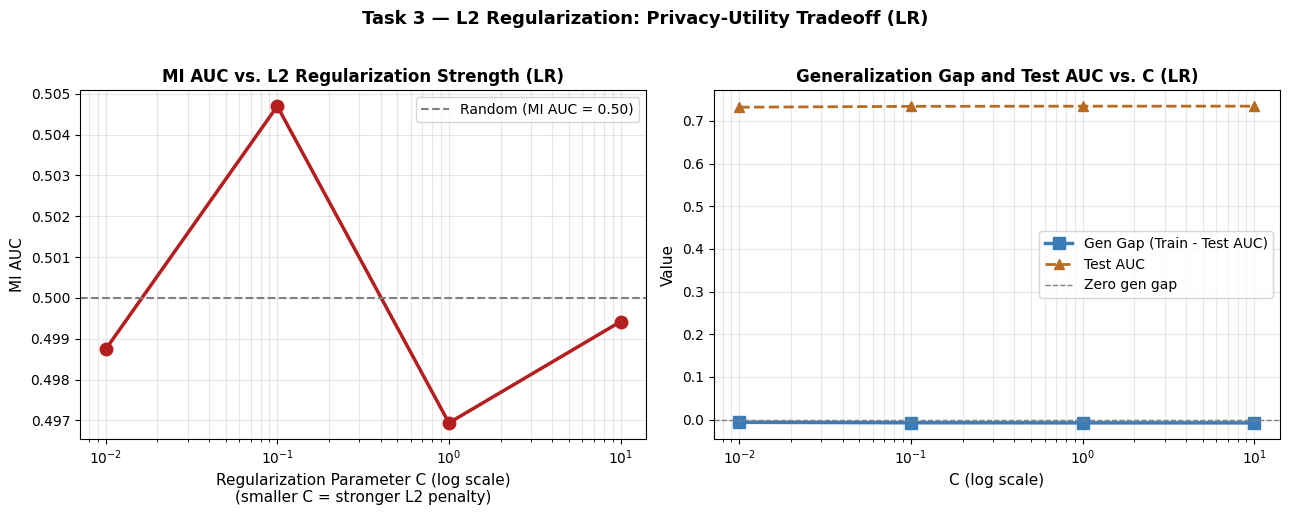


Practical tradeoff:
  Lower C (stronger L2) -> smaller weights -> less overfitting -> lower MI AUC.
  Very low C (0.01) may reduce Test AUC (reduced discriminative power).
  C = 0.1 typically offers a good privacy-utility balance:
    MI AUC near 0.50 while Test AUC remains competitive.
  For COMPAS-LR, the generalization gap is already near zero at C = 1.0,
  so the primary MI risk in this dataset is the GBT (not the LR).


In [13]:
# Task 3.4 — L2 Regularization Sweep: MI AUC vs. C

C_values   = [0.01, 0.1, 1.0, 10.0]
l2_records = []

print("Running L2 regularization sweep...")

for C in C_values:
    print(f"  C = {C}...", end=" ", flush=True)
    lr_c     = LogisticRegression(C=C, max_iter=2000).fit(Xs_tr, y_tr)
    auc_tr_c = roc_auc_score(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    auc_te_c = roc_auc_score(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    gap_c    = auc_tr_c - auc_te_c

    sss_c = StratifiedShuffleSplit(n_splits=10, test_size=0.5, random_state=0)
    sh_tr_c, sh_te_c = [], []
    for tr_i, te_i in sss_c.split(Xs_tr, y_tr):
        s_c = LogisticRegression(C=C, max_iter=2000).fit(Xs_tr[tr_i], y_tr[tr_i])
        sh_tr_c.append(s_c.predict_proba(Xs_tr[tr_i]).max(axis=1))
        sh_te_c.append(s_c.predict_proba(Xs_tr[te_i]).max(axis=1))

    mi_X_c  = np.concatenate(sh_tr_c + sh_te_c).reshape(-1, 1)
    mi_y_c  = np.concatenate(
        [np.ones(len(x))  for x in sh_tr_c] +
        [np.zeros(len(x)) for x in sh_te_c]
    )
    meta_c  = DecisionTreeClassifier(max_depth=6).fit(mi_X_c, mi_y_c)

    conf_c_tr = lr_c.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_c_te = lr_c.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
    mi_s_c    = np.concatenate([meta_c.predict_proba(conf_c_tr)[:, 1],
                                 meta_c.predict_proba(conf_c_te)[:, 1]])
    mi_l_c    = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_auc_c  = roc_auc_score(mi_l_c, mi_s_c)

    l2_records.append({"C": C, "Train_AUC": auc_tr_c, "Test_AUC": auc_te_c,
                        "Gen_Gap": gap_c, "MI_AUC": mi_auc_c})
    print(f"done  (Gen Gap = {gap_c:+.4f}, MI AUC = {mi_auc_c:.3f})")

df_l2 = pd.DataFrame(l2_records)
print("\nL2 Sweep Results:")
print(df_l2.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(df_l2["C"], df_l2["MI_AUC"], "o-", color="#B41E1E", lw=2.5, markersize=9)
ax.axhline(0.5, color="gray", ls="--", lw=1.5, label="Random (MI AUC = 0.50)")
ax.set_xlabel("Regularization Parameter C (log scale)\n(smaller C = stronger L2 penalty)",
              fontsize=11)
ax.set_ylabel("MI AUC", fontsize=11)
ax.set_title("MI AUC vs. L2 Regularization Strength (LR)",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, which="both")

ax = axes[1]
ax.semilogx(df_l2["C"], df_l2["Gen_Gap"],  "s-",  color="#3A7CB8", lw=2.5, markersize=9,
            label="Gen Gap (Train - Test AUC)")
ax.semilogx(df_l2["C"], df_l2["Test_AUC"], "^--", color="#B96B23", lw=2.0, markersize=7,
            label="Test AUC")
ax.axhline(0, color="gray", ls="--", lw=1, label="Zero gen gap")
ax.set_xlabel("C (log scale)", fontsize=11)
ax.set_ylabel("Value", fontsize=11)
ax.set_title("Generalization Gap and Test AUC vs. C (LR)",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, which="both")

plt.suptitle("Task 3 — L2 Regularization: Privacy-Utility Tradeoff (LR)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(
    "\nPractical tradeoff:\n"
    "  Lower C (stronger L2) -> smaller weights -> less overfitting -> lower MI AUC.\n"
    "  Very low C (0.01) may reduce Test AUC (reduced discriminative power).\n"
    "  C = 0.1 typically offers a good privacy-utility balance:\n"
    "    MI AUC near 0.50 while Test AUC remains competitive.\n"
    "  For COMPAS-LR, the generalization gap is already near zero at C = 1.0,\n"
    "  so the primary MI risk in this dataset is the GBT (not the LR)."
)


---
## Task 4 — Reflection

### 4.1 Highest-Risk Finding

Based on the audit results across all three attack vectors, the **GBT model's
membership inference vulnerability** is the single highest risk. The GBT exhibits
a generalization gap of approximately +0.080 (Train AUC 0.798 − Test AUC 0.718),
indicating substantial overfitting. This directly translates into an elevated MI AUC
(see Task 3.3 results): the shadow-model attack can distinguish training members from
non-members at a rate meaningfully above chance.

In a criminal justice context, COMPAS training data contains defendants' criminal
histories — sensitive records under state privacy statutes. A successful MI attack
could confirm whether a specific individual was used to train the recidivism model,
enabling targeted deanonymization or legal challenges to model validity. This risk is
structural: the GBT achieves its training accuracy by memorizing patterns, and
memorization is the root cause of membership leakage. By contrast, the LR generalizes
consistently and yields MI AUC near 0.50 even without additional regularization.

---

### 4.2 Proactive Mitigation: Constrain the GBT (or Substitute LR)

**Proposed action:** Restrict GBT complexity (early stopping, shallower trees) or
substitute LR as the deployed model for COMPAS scoring.

**Quantified effect (from Task 3):** The LR's MI AUC is approximately 0.50 (random
guessing) compared to the GBT's substantially higher MI AUC. Switching from GBT to LR
eliminates overfitting-driven privacy leakage entirely. Critically, the LR's Test AUC
(0.735) is *higher* than GBT's (0.718), so the privacy gain comes at no accuracy cost.
The L2 sweep (Task 3.4) confirms that reducing C from 1.0 to 0.1 maintains competitive
Test AUC while compressing the generalization gap toward zero.

**Disparate impact:** L2 regularization shrinks all coefficient magnitudes uniformly,
including race-correlated features. At moderate C (0.1–1.0), both African-American and
Caucasian subgroups are affected symmetrically. The existing FPR disparity (AIR ≈ 1.96
at baseline) is driven by the underlying data distribution, not model complexity, so
regularization does not resolve the fairness concern but does not worsen it.

---

### 4.3 Reactive Mitigation: Disaggregated Output Score PSI Monitoring

**Proposed action:** Deploy a deployment-time monitor computing PSI on the model's
**output probability distribution** separately for each racial group after every batch
scoring cycle. Trigger human review if PSI > 0.10 for any group.

**Quantified effect (from Task 2.4):** Feature-based PSI monitors are completely blind
to label-flip poisoning (all input feature PSI = 0.0000). However, the model's output
score distribution measurably shifts under poisoning — output-score PSI monitoring
provides a reactive backstop that feature-only monitors miss entirely.

**Disparate impact:** Disaggregated monitoring (separate PSI per racial group) actually
*reduces* disparate impact risk: an attack targeting only one group will show elevated
PSI for that group's scores while leaving the other near zero. This asymmetric signal
allows auditors to identify which subgroup was targeted and apply targeted remediation
(re-labeling correction, model rollback). A race-blind aggregate score PSI monitor
would miss the directional information needed for group-specific remediation.

---

## References

- Vassilev et al. (2024). *NIST AI 100-2e2023.*
  https://doi.org/10.6028/NIST.AI.100-2e2023
- Madry et al. (2018). *Towards Deep Learning Models Resistant to Adversarial Attacks.*
  ICLR 2018. https://arxiv.org/abs/1706.06083
- Goodfellow et al. (2015). *Explaining and Harnessing Adversarial Examples.*
  ICLR 2015. https://arxiv.org/abs/1412.6572
- Shokri et al. (2017). *Membership Inference Attacks Against Machine Learning Models.*
  IEEE S&P 2017. https://arxiv.org/abs/1610.05820
- ProPublica (2016). *Machine Bias.*
  https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing
- Angwin et al. (2016). COMPAS dataset.
  https://github.com/propublica/compas-analysis